In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from functions import Functions
from OceanDataStore import OceanDataCatalog


pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings

fname_zhou = '../data/CLIM_3D_forJenny.nc'
fname_spira = '../data/qc_profile_ds_2dbar.nc'
fname_glorys1 = '../data/GLORYS/glorys_001.nc'
fname_glorys2 = '../data/GLORYS/glorys_002.nc'

In [4]:
extent = [138, 150,-68,-64]
extent2 = [139,142,-67,-66]

In [5]:
en4 = xr.open_dataset('en4_analysis.nc')
en4 = en4.sel(lat=slice(extent2[2],extent2[3]),lon=slice(extent2[0],extent2[1]))

In [6]:
t1 = en4.time[0]
t2 = en4.time[-1]

In [ ]:
# ds1 = xr.open_dataset(fname_glorys1)
# ds2 = xr.open_dataset(fname_glorys2)
# glorys = xr.merge([ds1,ds2])
# glorys_shelf = glorys.sel(latitude=slice(extent2[2],extent2[3])).sel(longitude=slice(extent2[0],extent2[1])).sel(time=slice(t1,t2))
# glorys_shelf['month'] = glorys_shelf.time.dt.month
# glorys_shelf.to_netcdf('glorys_en4.nc')

/tmp/ipykernel_336865/439258241.py:3: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  glorys = xr.merge([ds1,ds2])


In [8]:
# load nemo data
# catalog = OceanDataCatalog(catalog_name="noc-model-stac")
# nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_4d',variable_names=['thetao_con','so_abs'])

# # prepare nemo
# # crop to region
# lats = nemo.nav_lat.load()
# lons = nemo.nav_lon.load()
# mask = (lats >= extent2[2]) & (lats <= extent2[3]) & (lons >= extent2[0]) & (lons <= extent2[1])
# nemo_shelf = nemo.where(mask,drop=True)

# # make monthly
# nemo_shelf=nemo_shelf.resample({'time_counter':'MS'}).mean().sel(time_counter=slice(t1,t2))
# nemo_shelf.load()
# nemo_shelf['month'] = nemo_shelf.time_counter.dt.month

  2026-04-08T14:29:41.434414Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: HTTP read timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: HttpTimeoutError { kind: "HTTP read", duration: 1s }, connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



In [11]:
glorys_shelf = xr.open_dataset('glorys_en4.nc').mean(['latitude','longitude'])
nemo_shelf = xr.open_dataset('nemo_en4.nc').mean(['y','x'])

In [10]:
en4

<xarray.Dataset> Size: 3MB
Dimensions:                          (time: 216, depth: 42, lat: 2, lon: 4,
                                      bnds: 2)
Coordinates:
  * time                             (time) datetime64[ns] 2kB 2007-01-16T12:...
  * depth                            (depth) float32 168B 5.022 ... 5.35e+03
  * lat                              (lat) float32 8B -67.0 -66.0
  * lon                              (lon) float32 16B 139.0 140.0 141.0 142.0
Dimensions without coordinates: bnds
Data variables:
    temperature                      (time, depth, lat, lon) float64 581kB ...
    salinity                         (time, depth, lat, lon) float64 581kB ...
    temperature_uncertainty          (time, depth, lat, lon) float64 581kB ...
    salinity_uncertainty             (time, depth, lat, lon) float64 581kB ...
    temperature_observation_weights  (time, depth, lat, lon) float32 290kB ...
    salinity_observation_weights     (time, depth, lat, lon) float32 290kB ...
    time_bnds                        (time, bnds) datetime64[ns] 3kB ...
    depth_bnds                       (time, depth, bnds) float32 73kB ...
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

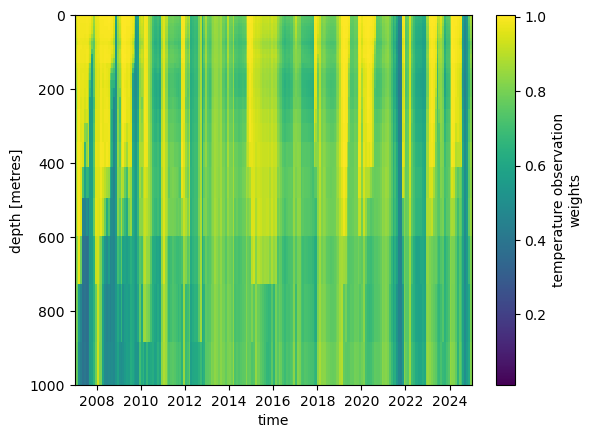

In [17]:
en4.mean(['lat','lon']).temperature_observation_weights.plot(x='time')
plt.gca().set_ylim([0,1000])
plt.gca().invert_yaxis()


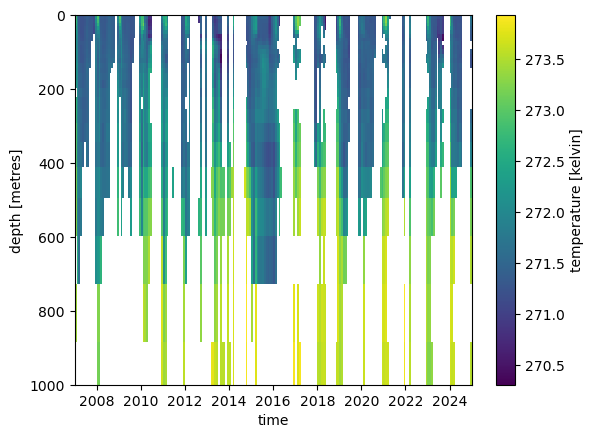

In [22]:
en4mean=en4.mean(['lat','lon'])
en4mean.where(en4mean.temperature_observation_weights > 0.8).temperature.plot(x='time')
plt.gca().set_ylim([0,1000])
plt.gca().invert_yaxis()

In [28]:
en4['month'] = en4.time.dt.month
en4 = en4.mean(['lat','lon'])

ValueError: Dimension(s) 'lon', 'lat' do not exist. Expected one or more of {'time', 'depth', 'bnds'}

In [29]:
en4_ssn = fns.get_seasons(en4.sel(depth=slice(100,300)).mean('depth'))
glo_ssn = fns.get_seasons(glorys_shelf.sel(depth=slice(100,300)).mean('depth'))
nmo_ssn = fns.get_seasons(nemo_shelf.sel(deptht=slice(100,300)).mean('deptht'))


In [ ]:
fig,ax= plt.subplots(figsize=(12,3))
colors = ['steelblue','lightseagreen','palevioletred']

offset = {'summer':0,'autumn':0.25,'winter':0.5,'spring':0.75}
for c,s in zip(colors,en4_ssn):
    data = en4_ssn[s].temperature.groupby('time.year').mean() - 273.15
    ax.plot(data.year+offset[s],data,marker='x',label=s,linestyle='--',c=c)
ax.legend()

In [40]:
nemo_shelf

<xarray.Dataset> Size: 133kB
Dimensions:       (time_counter: 215, deptht: 75)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2kB 2007-02-01 ... 2024-12-01
  * deptht        (deptht) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
Data variables:
    thetao_con    (time_counter, deptht) float32 64kB -1.062 -1.054 ... nan nan
    so_abs        (time_counter, deptht) float32 64kB 33.82 33.83 ... nan nan
    month         (time_counter) int64 2kB 2 3 4 5 6 7 8 9 ... 6 7 8 9 10 11 12
Attributes:
    name:         OUTPUT/eORCA12_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Dec-03 20:51:31 GMT
    uuid:         a8ac37d1-a8ff-4925-b791-f0d6111ec8e1

In [50]:
data_u

<xarray.DataArray 'temperature_uncertainty' (year: 18)> Size: 144B
array([0.22647508, 0.22741604, 0.24232366, 0.26780672, 0.26060797,
       0.29606939, 0.27463743, 0.27654641, 0.23318655, 0.28647034,
       0.28171727, 0.27197312, 0.23263398, 0.2357241 , 0.30157552,
       0.31552007, 0.25453133, 0.25832187])
Coordinates:
  * year     (year) int64 144B 2007 2008 2009 2010 2011 ... 2021 2022 2023 2024
Attributes:
    long_name:  temperature error standard deviation
    units:      kelvin

In [1]:
fig,ax= plt.subplots(figsize=(12,3))
colors = ['steelblue','lightseagreen','palevioletred']


data = en4.sel(depth=slice(100,300)).mean('depth').groupby('time.year').mean()
data_t = data.temperature - 273.15
data_u = data.temperature_uncertainty
ax.plot(data_t.year,data_t,label='en4',linestyle='-',c=colors[0])
ax.fill_betweenx(data_t.time, data_t - data_u, data_t + data_u, alpha=0.3, label='±1 std')

data = glorys_shelf.thetao.sel(depth=slice(100,300)).mean('depth').groupby('time.year').mean()
ax.plot(data.year,data,label='glorys',linestyle='--',c=colors[1])

data = nemo_shelf.thetao_con.sel(deptht=slice(100,300)).mean('deptht').groupby('time_counter.year').mean()
ax.plot(data.year,data,label='nemo',linestyle='--',c=colors[2])

ax.legend()

NameError: name 'plt' is not defined

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

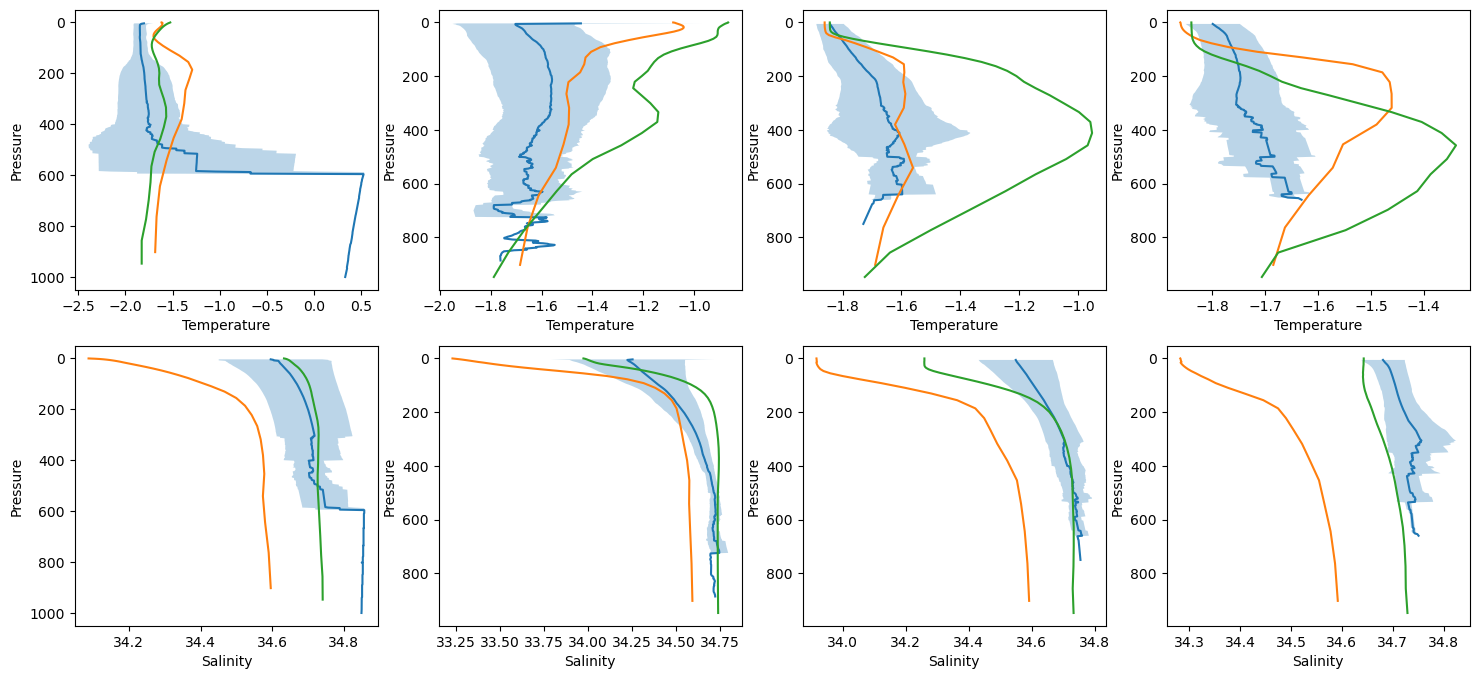

In [30]:
fig, axs = plt.subplots(2,4,figsize=(18,8))

def plot_var(ax,s,p_var,g_var,o_var,label):
    mean_temp = sps[s][p_var].mean(dim='time', skipna=True)
    mean_temp_g = sgs[s][g_var].mean(['time','latitude','longitude'])
    mean_temp_o = sos[s][o_var].mean(['time_counter','x','y'])

    std_temp  = sps[s][p_var].std(dim='time', skipna=True)

    # Mean line
    ax.plot(mean_temp,  sps[s]['pres'], label=['profiles'])
    ax.plot(mean_temp_g,mean_temp_g.depth,label='glorys')
    ax.plot(mean_temp_o,mean_temp_o.deptht,label='nemo')

    # Shaded region (choose ONE)
    ax.fill_betweenx(sps[s].pres, mean_temp - std_temp, mean_temp + std_temp, alpha=0.3, label='±1 std')

    ax.invert_yaxis()
    ax.set_xlabel(label)
    ax.set_ylabel('Pressure')

for i,s in enumerate(['spring','summer','autumn','winter']):
    ax=axs.T[i]

    plot_var(ax[0],s,'ctemp','thetao','thetao_con','Temperature')
    plot_var(ax[1],s,'asal','so','so_abs','Salinity')



In [31]:
glorys_shelf_interpolated = glorys_shelf.interp(depth=profiles.pres)


In [32]:
glorys_shelf_interpolated

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 190, latitude: 13, longitude: 36, pres: 501)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2007-03-01 2007-04-01 ... 2022-12-01
  * latitude   (latitude) float32 52B -67.0 -66.92 -66.83 ... -66.08 -66.0
  * longitude  (longitude) float32 144B 139.0 139.1 139.2 ... 141.8 141.8 141.9
  * pres       (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
    depth      (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    siconc     (time, latitude, longitude, pres) float64 356MB nan nan ... nan
    mlotst     (time, latitude, longitude, pres) float64 356MB nan nan ... nan
    sithick    (time, latitude, longitude, pres) float64 356MB nan nan ... nan
    zos        (time, latitude, longitude, pres) float64 356MB nan nan ... nan
    thetao     (time, pres, latitude, longitude) float64 356MB nan nan ... nan
    so         (time, pres, latitude, longitude) float64 356MB nan nan ... nan
    bottomT    (time, latitude, longitude, pres) float64 356MB nan nan ... nan
    uo         (time, pres, latitude, longitude) float64 356MB nan nan ... nan
    vo         (time, pres, latitude, longitude) float64 356MB nan nan ... nan
    month      (time) float64 2kB 3.0 4.0 5.0 6.0 7.0 ... 8.0 9.0 10.0 11.0 12.0
Attributes:
    Conventions:       CF-1.11
    title:             Monthly mean fields for product GLOBAL_REANALYSIS_PHY_...
    institution:       Mercator Ocean
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MERCATOR GLORYS12V1
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_my_0.083deg_P1M-m_202311
    subset:date:       2025-12-04T07:49:47.532Z

In [ ]:
# choose depth to average over
zz = 300

max_depth = profiles_shelf.pres.where(~np.isnan(profiles_shelf.temp)).max(dim="pres")
ds_z = ds_shelf.where(max_depth > zz,drop=True).sel(pres=slice(0,zz))


In [14]:
# set up colours
allyears = ds.groupby('time.year').mean().year
colors = plt.cm.tab20(np.linspace(0, 1, len(allyears)))
cdict = dict(zip(allyears.to_numpy(),colors))

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


In [15]:
ds_400 = ds_shelf.sel(pres=slice(0,400)).mean('pres')

In [32]:
n_min = 10

ds_zz = ds_z.mean('pres')
mon_mean_ = ds_zz.resample({'time':'MS'}).mean()
mon_std = ds_zz.resample({'time':'MS'}).std()
mon_count = ds_zz.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean = mon_mean_.where(mon_count > n_min, drop=True)
mon_std = mon_std.where(mon_count > n_min, drop=True)

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

In [35]:
cli_count = mon_mean.groupby('time.month').count()

cli_mean = mon_mean.groupby('time.month').mean()
cli_std = mon_mean.groupby('time.month').std()

cli_mean = cli_mean.where(cli_count.temp > 1,drop=True)
cli_std = cli_std.where(cli_count.temp >1,drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/

In [18]:
df=mon_mean.groupby('time.month').where(cli_count.temp > 1).to_dataframe()

In [19]:
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

In [42]:
y

2013

In [49]:
mon_mean_

<xarray.Dataset> Size: 21kB
Dimensions:    (time: 205)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2007-02-01 2007-03-01 ... 2024-02-01
Data variables:
    temp       (time) float64 2kB -1.229 -1.707 -1.706 -1.752 ... nan nan -1.491
    psal       (time) float64 2kB 34.19 34.2 34.39 34.44 ... nan nan nan 34.24
    mld        (time) float64 2kB 46.53 176.9 132.3 92.21 ... nan nan nan nan
    asal       (time) float64 2kB 34.35 34.36 34.55 34.61 ... nan nan nan 34.41
    ctemp      (time) float64 2kB -1.229 -1.707 -1.706 -1.752 ... nan nan -1.491
    rho        (time) float64 2kB 1.028e+03 1.028e+03 ... nan 1.028e+03
    mlp        (time) float64 2kB 42.55 172.1 123.9 82.53 ... nan nan nan nan
    gph        (time) float64 2kB nan nan nan nan nan ... nan nan nan nan nan
    elevation  (time) float64 2kB -309.7 -347.2 -580.7 -323.3 ... nan nan -434.3
    month      (time) float64 2kB 2.0 3.0 4.0 5.0 6.0 ... nan nan nan nan 2.0
    year       (time) float64 2kB 2.007e+03 2.007e+03 ... nan 2.024e+03
    sigma0     (time) float64 2kB 27.51 27.53 27.69 27.73 ... nan nan nan 27.56
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [ ]:
mon_count.where(mon_count.temp > 0).groupby('time.year').count()

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


<xarray.Dataset> Size: 2kB
Dimensions:    (year: 18)
Coordinates:
  * year       (year) int64 144B 2007 2008 2009 2010 ... 2021 2022 2023 2024
Data variables:
    temp       (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    psal       (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    mld        (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    asal       (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    ctemp      (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    rho        (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    mlp        (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    gph        (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    elevation  (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    month      (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
    sigma0     (year) int64 144B 8 9 6 4 3 2 0 2 1 0 2 6 1 1 0 0 8 1
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [43]:
np.nan_to_num(mon_count.temp.where(mon_mean_.year==y,drop=True))#.groupby('time.month').mean().broadcast_like(cli_count.month))

array([], dtype=float64)

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this ob

ValueError: month must not be empty

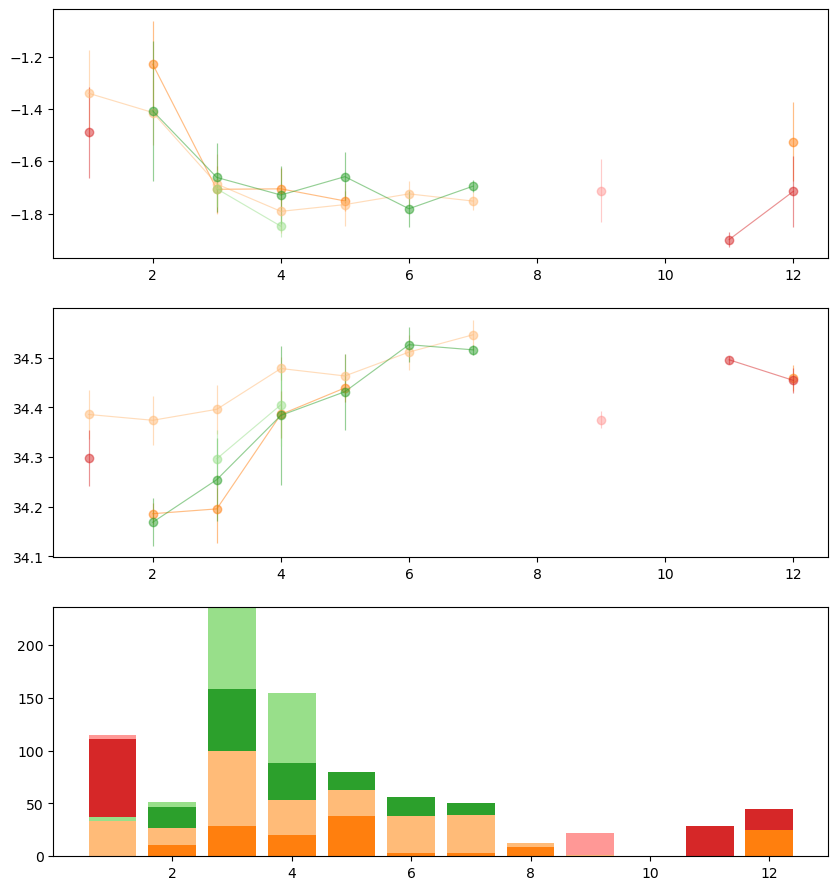

In [ ]:
# # plot to demonstrate types of variailty
# dscrop = ds_400.sel(time=slice(pd.Timestamp(2007,1,1),pd.Timestamp(2008,1,1)))
# dscropmon = dscrop.groupby('time.month').mean()
# dscropmonstd = dscrop.groupby('time.month').std()

# fig,axs = plt.subplots(2,1,figsize=(10,5))
# ax=axs[0]
# ax.scatter(dscrop.month,dscrop.temp)
# ax.errorbar(dscropmon.month,dscropmon.temp,yerr=dscropmonstd.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# ax=axs[1]
# ax.scatter(mon_mean.month,mon_mean.temp)
# ax.errorbar(cli_mean.month,cli_mean.temp,yerr=cli_std.temp,c='r')
# ax.set_ylabel('Temperature')
# ax.set_xticks(np.arange(1,13),labels=month_labels)

# plt.tight_layout()

# mnothly variability plot
fig,axs = plt.subplots(3,1,figsize=(10,11))
mon_year = mon_mean.groupby('time.year').mean()
moc_year = mon_count.where(mon_count.temp).groupby('time.year').count()


ax=axs[0]
cx=axs[1]
bx=axs[2]

for y_da in moc_year.year:
    y = y_da.item()
    data = mon_mean.where(mon_mean.year==y,drop=True)
    dats = mon_std.where(mon_mean.year==y,drop=True)
    if not len(data.time) ==0:
        clim = data.groupby('time.month').mean().broadcast_like(cli_count.month)
        clis = dats.groupby('time.month').mean().broadcast_like(cli_count.month)

        # temperature
        ax.errorbar(clim.month,clim.temp,yerr=clis.temp,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])
        
        # salinity
        cx.errorbar(clim.month,clim.psal,yerr=clis.psal,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])

    # histogram
    year_count = np.nan_to_num(mon_count.temp.where(mon_mean_.year==y,drop=True).groupby('time.month').mean().broadcast_like(cli_count.month))
    if y > 2007:
        bx.bar(cli_count.month, year_count, bottom = bottom,color=cdict[y],label=str(y))
        bottom = bottom + year_count
    else:
        bx.bar(cli_count.month, year_count,color=cdict[y],label=str(y))
        bottom = year_count.copy()
        

#ax.legend(loc='best',fontsize=2)
bx.legend(ncol=7,fontsize='small')
bx.set_ylabel('Number of Profiles')
bx.set_xticks(np.arange(1,13),labels=month_labels)


sns.lineplot(
    data=df,
    x="month", y="temp", errorbar=("pi",90), ax=ax, 
)
  
sns.lineplot(
    data=df,
    x="month", y="psal", errorbar=("pi",90), ax=cx
)

ax.grid(alpha=0.3)
ax.set_xticks(np.arange(1,13),labels=month_labels)
ax.set_ylabel('Temperature')
ax.set_xlabel(None)

cx.grid(alpha=0.3)
cx.set_xticks(np.arange(1,13),labels=month_labels)
cx.set_ylabel('Salinity')
cx.set_xlabel(None)

plt.tight_layout()



In [126]:
mon_mean = ds_shelf.resample({'time':'MS'}).mean()
mon_std = ds_shelf.resample({'time':'MS'}).std()
mon_quants = ds_shelf.drop_vars(['dsource','profile_code']).resample({'time':'MS'}).quantile([0.1,0.9])
mon_iqr = mon_quants.sel(quantile=0.9) - mon_quants.sel(quantile=0.1)
mon_count = ds_shelf.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean = mon_mean.where(mon_count > n_min, drop=True)
mon_std = mon_std.where(mon_count > n_min, drop=True)
mon_iqr = mon_iqr.where(mon_count > n_min, drop=True)

cli_count = mon_mean.groupby('time.month').count().broadcast_like(cli_count)
cli_mean = mon_mean.groupby('time.month').mean().broadcast_like(cli_count)
cli_std = mon_mean.groupby('time.month').std().broadcast_like(cli_count)
cli_quants = mon_mean.drop_vars(['month']).groupby('time.month').quantile([0.1,0.9]).broadcast_like(cli_count)
cli_iqr = cli_quants.sel(quantile=0.9) - cli_quants.sel(quantile=0.1).broadcast_like(cli_count)




# make sure all months used have more than n profiles
# cli_mean = cli_mean.where(cli_count.temp > 1,drop=True)
# cli_std = cli_std.where(cli_count.temp >1,drop=True)
# cli_iqr = cli_iqr.where(cli_count.temp >1,drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

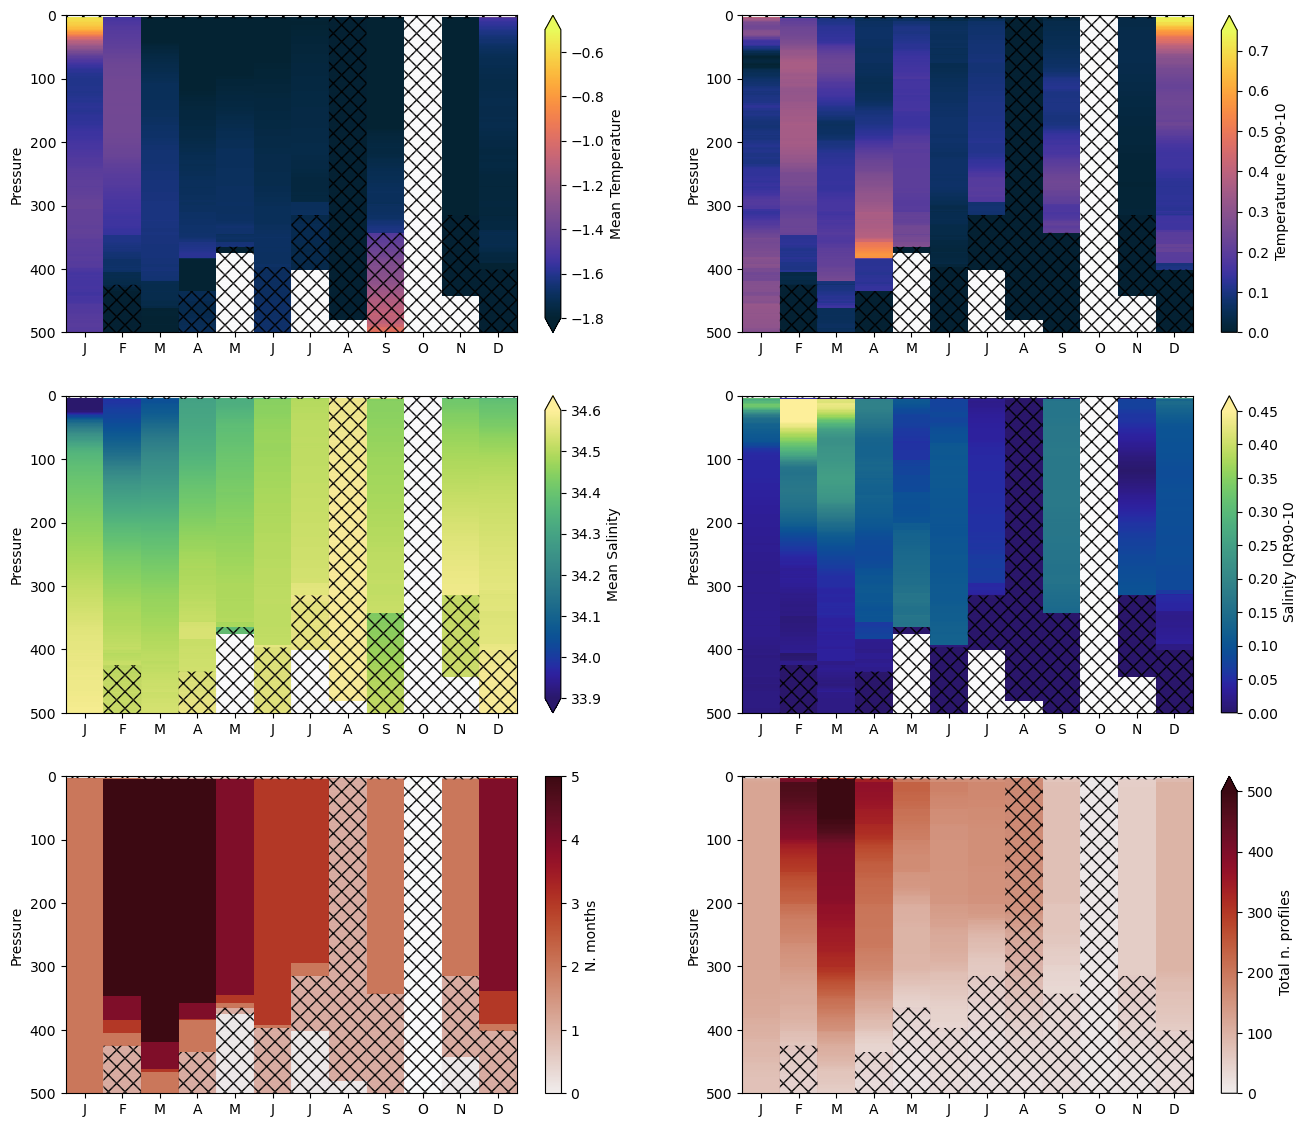

In [174]:
fig, ax = plt.subplots(3,2,figsize=(16,14))

mask = (cli_count.temp < 2) | np.isnan(cli_count.temp)

hatch_layer = xr.where(mask, 1, np.nan)

Z = hatch_layer.values

def edges(coord):
    c = coord.values
    d = np.diff(c)/2
    return np.concatenate(([c[0]-d[0]], c[:-1]+d, [c[-1]+d[-1]]))

Xe = edges(hatch_layer['month'])
Ye = edges(hatch_layer['pres'])

def presvmonth(ax,data,label,cmap,c1=None,c2=None):
    im=data.plot(ax=ax,x='month',y='pres',cmap=cmap,vmin=c1,vmax=c2)

    ax.pcolor(Xe, Ye, Z, #hatch_layer,
        alpha=0.01,
        hatch='xx'
    )
        
    ax.invert_yaxis()
    ax.set_ylabel('Pressure')
    im.colorbar.set_label(label)
    ax.set_xticks(np.arange(1,13),labels=month_labels)
    ax.set_xlabel(None)
    ax.set_ylim([500,0])


presvmonth(ax[0][0],cli_mean.temp,'Mean Temperature',cmap=cmocean.cm.thermal,c1=-1.8,c2=-0.5)
presvmonth(ax[0][1],cli_iqr.temp,'Temperature IQR90-10',cmocean.cm.thermal,c1=0,c2=0.75)

presvmonth(ax[1][0],cli_mean.psal,'Mean Salinity',cmap=cmocean.cm.haline,c1=33.9,c2=34.6)
presvmonth(ax[1][1],cli_iqr.psal,'Salinity IQR90-10',cmocean.cm.haline,c1=0,c2=0.45)

presvmonth(ax[2][0],cli_count.temp,'N. months',cmocean.cm.amp,c1=0,c2=5)
presvmonth(ax[2][1],mon_count.psal.groupby('time.month').sum(),'Total n. profiles',cmocean.cm.amp,c1=0,c2=500)


In [23]:
year_count = ds_shelf.groupby('time.year').count()
cdict = dict(zip(year_count.year.to_numpy(),colors))


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


/tmp/ipykernel_751413/3356611935.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()],label=str(y.item())))
/tmp/ipykernel_751413/3356611935.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()],label=str(y.item())))
/tmp/ipykernel_751413/3356611935.py:8: UserWarning: *c* argument looks l

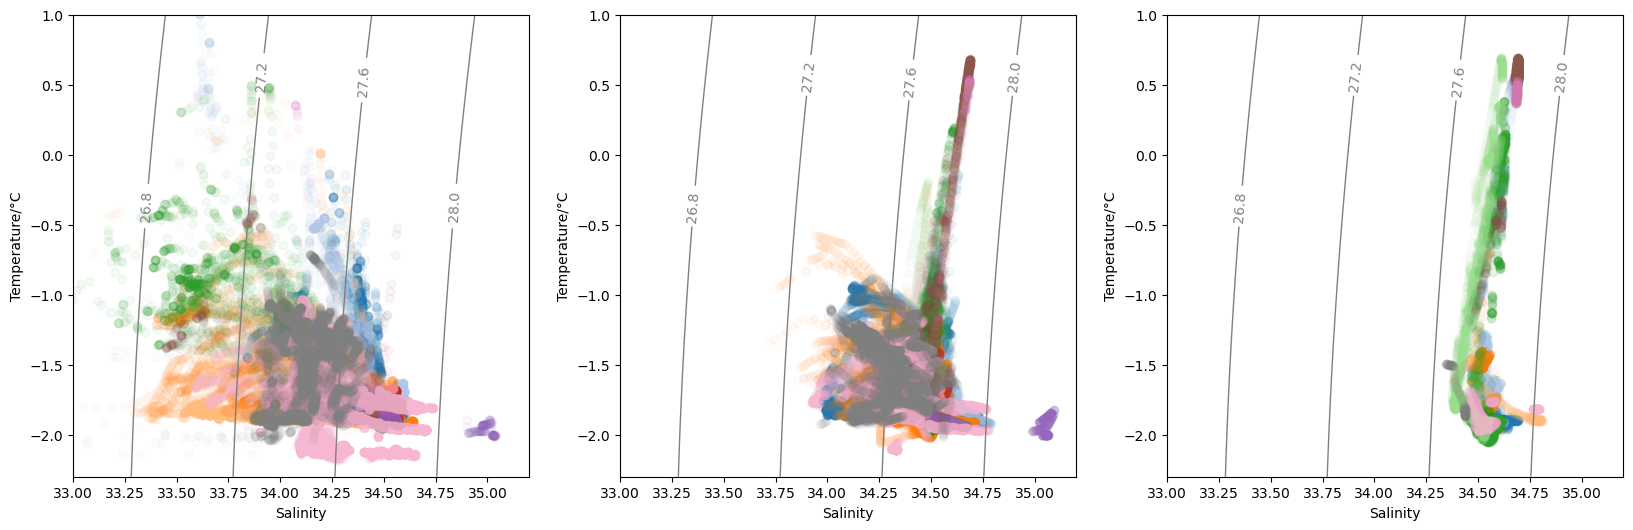

In [27]:
fig, ax = plt.subplots(1,3,figsize=(20,6))

ims=[]
def ts_plot(ax,z1,z2):
    for y in year_count.year:
        data = ds_shelf.where(ds_shelf.year==y,drop=True).where(max_depth > z2,drop=True).sel(pres=slice(z1,z2))
        if not len(data.time) ==0:
            ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()],label=str(y.item())))

            

    tlim=[-2.3,1]
    slim=[33,35.2]
    temprange,psalrange,sig0range_ = sig0range(tlim,slim)
    cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
    plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
    ax.set_xlim(slim)
    ax.set_ylim(tlim)
    ax.set_ylabel('Temperature/°C')
    ax.set_xlabel('Salinity')

ts_plot(ax[0],0,100)
ts_plot(ax[1],100,300)
ts_plot(ax[2],300,600)
